# Breaking Points: Do Topic Choices Reveal Editorial Incentives?
## A Within-Day Fixed Effects Analysis of Political Media Viewership

**Channel:** Breaking Points with Krystal and Saagar (YouTube)  
**Sample:** 171 video segments across 33 days (~7 weeks)  
**Outcome:** log(view count)  
**Treatment:** topic category (LLM-labeled from title, 9-category fixed taxonomy)

---

### The question

Political commentary channels face a structural tension: they have editorial commitments to cover what *matters*, but they also depend on advertising revenue that scales with views. If some topics systematically outperform others in viewership, a channel faces a financial incentive to tilt its editorial mix toward those topics — regardless of their actual newsworthiness.

This project measures that incentive directly. **Do certain topics drive more views on Breaking Points, and how large is the effect after controlling for which day the content aired?**

### The identification strategy

Breaking Points publishes 5–8 segments per day, each covering a different topic. The host pair is fixed within a day. This structure creates a natural within-day control group: **all segments published on a given day share the same hosts, the same news-cycle conditions, and the same day-level algorithmic promotion state.** Any within-day variation in views must therefore come from the segment itself — primarily its topic.

Formally, we estimate:

$$\log(\text{views}_{id}) = \alpha_d + \beta \cdot \text{topic}_i + \gamma \cdot \text{position}_i + \delta \cdot \log(\text{duration}_i) + \varepsilon_{id}$$

where $\alpha_d$ is a **day fixed effect** absorbing: host identity, news-cycle magnitude, day-of-week audience patterns, and day-level algorithmic variation. The coefficient $\beta$ is identified off within-day topic variation across segments.

A variance decomposition confirms the design is viable: **47.9% of log(view) variance is within-day**, ensuring the day FE doesn't swamp the signal.

Robustness (permutation test, alternative outcomes, full-sample sensitivity, position mechanism) are in **notebook 02**.

### Why not estimate host effects directly?

We checked. The channel follows a near-rigid weekly rotation: Krystal & Saagar on Mon/Tue/Thu, Ryan & Emily on Wed. Day-of-week predicts the host pair with ~80% accuracy, leaving almost no residual variation to identify a host effect after conditioning on the news cycle. Only 2 of 33 days in this sample show within-day host variation — not enough. We note this explicitly and propose the host analysis as a stated extension requiring the full historical archive (~3,000 videos).

In [1]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('../data/analysis_dataset_clean.csv', parse_dates=['upload_date'])
df['date'] = df['date'].astype(str)

# Collapse thin topic cells (< 5 obs) into "Other" to avoid unstable estimates
MIN_TOPIC_N = 5
topic_counts = df['topic'].value_counts()
thin_topics  = topic_counts[topic_counts < MIN_TOPIC_N].index.tolist()
if thin_topics:
    print(f"Collapsing {thin_topics} → 'Other' (fewer than {MIN_TOPIC_N} segments each)")
    df['topic'] = df['topic'].apply(lambda t: 'Other' if t in thin_topics else t)

# Age-confound check: views correlate with video age, but day FE differences it out.
# All within-day segments share the same upload date → same age → day FE removes age bias.
# This is an advantage of the design vs. naive pooled OLS.
df['days_old'] = (pd.Timestamp('2026-06-12') - df['upload_date']).dt.days
r_age = np.corrcoef(df['log_views'], df['days_old'])[0, 1]

print(f"N = {len(df)} segments across {df['date'].nunique()} days")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"\nAge confound: corr(log_views, days_old) = {r_age:.3f}")
print("  → Addressed automatically: all within-day segments share the same age,")
print("    so day FE differences out view-accumulation time.")
print(f"\nTopic distribution (post-collapse):")
print(df['topic'].value_counts().to_string())
print(f"\nSegment position source: real YouTube publish timestamps (Unix epoch, second-level precision).")
print("  → Not yt-dlp playlist order. Fetched via per-video metadata calls in fetch_metadata.py.")

Collapsing ['Environment / Energy', 'Healthcare / Pharma', 'Immigration'] → 'Other' (fewer than 5 segments each)
N = 171 segments across 33 days
Date range: 2026-04-27 → 2026-06-12

Age confound: corr(log_views, days_old) = 0.350
  → Addressed automatically: all within-day segments share the same age,
    so day FE differences out view-accumulation time.

Topic distribution (post-collapse):
topic
Foreign Policy / War    70
Domestic Politics       43
Economy / Finance       21
Media / Tech            15
Culture / Society        9
Legal / Courts           8
Other                    5

Segment position source: real YouTube publish timestamps (Unix epoch, second-level precision).
  → Not yt-dlp playlist order. Fetched via per-video metadata calls in fetch_metadata.py.


## 1. Identification Check: Within-Day Variation

Before estimating anything, verify that the day fixed effects leave enough variation to identify topic effects. The question: do different topics actually appear on the same day, or are topics clustered by day in a way that makes them collinear with the FE?

In [2]:
# Variance decomposition: how much of log(views) is within-day?
overall_var  = df['log_views'].var()
day_means    = df.groupby('date')['log_views'].transform('mean')
between_var  = (day_means - df['log_views'].mean()).var()
within_var   = (df['log_views'] - day_means).var()

print("=== Variance decomposition: log(views) ===")
print(f"  Total variance:        {overall_var:.4f}")
print(f"  Between-day variance:  {between_var:.4f}  ({between_var/overall_var*100:.1f}%)")
print(f"  Within-day variance:   {within_var:.4f}  ({within_var/overall_var*100:.1f}%)")
print()
print("Nearly half of all view variation is within a single day (same hosts, same news cycle).")
print("This is the variation topic effects will be identified from.")

# Topic variety per day
topics_per_day = df.groupby('date')['topic'].nunique()
print(f"\nTopics per day: mean = {topics_per_day.mean():.1f}, min = {topics_per_day.min()}, max = {topics_per_day.max()}")
print("Most days cover multiple distinct topic categories — positivity holds.")

=== Variance decomposition: log(views) ===
  Total variance:        0.4361
  Between-day variance:  0.2271  (52.1%)
  Within-day variance:   0.2091  (47.9%)

Nearly half of all view variation is within a single day (same hosts, same news cycle).
This is the variation topic effects will be identified from.

Topics per day: mean = 3.2, min = 1, max = 5
Most days cover multiple distinct topic categories — positivity holds.


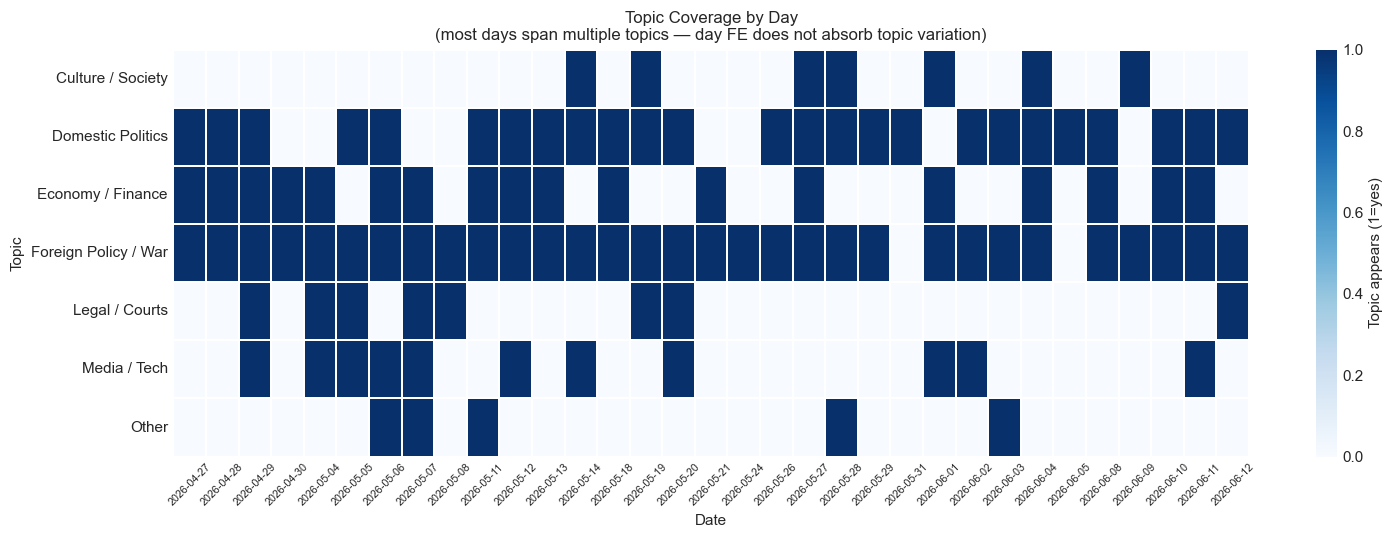

In [3]:
# Heatmap: which topics appear on which days?
topic_day = df.groupby(['date', 'topic']).size().unstack(fill_value=0)
topic_day_binary = (topic_day > 0).astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(topic_day_binary.T, ax=ax, cmap='Blues', linewidths=0.3,
            cbar_kws={'label': 'Topic appears (1=yes)'})
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Topic', fontsize=10)
ax.set_title('Topic Coverage by Day\n(most days span multiple topics — day FE does not absorb topic variation)', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout()
plt.savefig('../outputs/01_topic_day_coverage.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Naive Estimates (No Fixed Effects)

We start with the biased estimate to understand what we are correcting for. The naive OLS pools all videos without controlling for day — conflating topic effects with news-cycle effects. A topic that happened to be covered during a high-news week will look artificially popular.

In [4]:
# Set baseline topic (most common, to make coefficients interpretable as relative effects)
baseline_topic = df['topic'].value_counts().index[0]
print(f"Baseline topic (omitted category): {baseline_topic}")

# Encode topic with explicit baseline
df['topic_fe'] = pd.Categorical(df['topic'], categories=[baseline_topic] +
                  [t for t in df['topic'].unique() if t != baseline_topic])

# Naive OLS — no day FE
m_naive = smf.ols(
    'log_views ~ C(topic_fe) + log_duration + segment_position',
    data=df
).fit()

print("\n=== Naive OLS (no day FE) ===")
print(m_naive.summary().tables[1])
print(f"\nR² = {m_naive.rsquared:.3f}  |  N = {int(m_naive.nobs)}")

Baseline topic (omitted category): Foreign Policy / War

=== Naive OLS (no day FE) ===
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           12.1145      0.949     12.761      0.000      10.240      13.989
C(topic_fe)[T.Economy / Finance]    -0.1913      0.151     -1.271      0.206      -0.489       0.106
C(topic_fe)[T.Domestic Politics]    -0.6563      0.121     -5.417      0.000      -0.896      -0.417
C(topic_fe)[T.Media / Tech]         -0.3208      0.182     -1.763      0.080      -0.680       0.039
C(topic_fe)[T.Legal / Courts]       -0.7602      0.229     -3.315      0.001      -1.213      -0.307
C(topic_fe)[T.Other]                -0.9340      0.283     -3.295      0.001      -1.494      -0.374
C(topic_fe)[T.Culture / Society]    -0.4271      0.222     -1.922      0.056      -0.866       0.012
log_

## 3. Within-Day Fixed Effects Estimator

Now add day fixed effects. Each day absorbs the host pair, news-cycle magnitude, and algorithmic day-level variation. The topic coefficients now reflect within-day contrasts only — how much more or less does a segment get viewed compared to the other segments published that same day, given it covers a particular topic.

In [5]:
# Day FE model — clustered SEs by day.
# Rationale: all segments on the same day share a day-level shock (news cycle,
# algorithmic state). Treating them as independent understates uncertainty.
# We have 33 day-clusters — right at the edge of asymptotic validity (rule of
# thumb: 30–50+). We therefore lean on the permutation test in notebook 02,
# which gives nonparametric inference that doesn't require many clusters.
m_fe = smf.ols(
    'log_views ~ C(topic_fe) + log_duration + segment_position + C(date)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['date']})

# Extract topic coefficients and CIs (from clustered model)
topic_params = [
    (k.replace('C(topic_fe)[T.', '').replace(']', ''), v)
    for k, v in m_fe.params.items()
    if 'topic_fe' in k
]
topic_ci = {
    k.replace('C(topic_fe)[T.', '').replace(']', ''): m_fe.conf_int().loc[k]
    for k in m_fe.conf_int().index
    if 'topic_fe' in k
}

results_fe = pd.DataFrame([
    {'topic': t, 'beta': b,
     'lo': topic_ci[t][0], 'hi': topic_ci[t][1],
     'se': m_fe.bse[f'C(topic_fe)[T.{t}]'],
     'pval': m_fe.pvalues[f'C(topic_fe)[T.{t}]']}
    for t, b in topic_params
])
results_fe = pd.concat([
    results_fe,
    pd.DataFrame([{'topic': baseline_topic, 'beta': 0.0, 'lo': 0.0, 'hi': 0.0, 'se': 0.0, 'pval': np.nan}])
], ignore_index=True).sort_values('beta', ascending=False)

results_fe['pct_effect'] = (np.exp(results_fe['beta']) - 1) * 100

print("=== Day FE model: topic effects on log(views) ===")
print("    SEs clustered by day (33 clusters; permutation test in nb 02 for nonparametric p-values)")
print()
print(f"{'Topic':<28} {'β':>8} {'%effect':>10} {'95% CI (clustered)':>24} {'p-val':>8}")
print("-" * 84)
for _, row in results_fe.iterrows():
    pval_str = f"{row['pval']:.3f}" if not np.isnan(row['pval']) else 'baseline'
    ci_str   = f"[{row['lo']:+.3f}, {row['hi']:+.3f}]"
    sig = '*' if (not np.isnan(row['pval']) and row['pval'] < 0.05) else ''
    print(f"{row['topic']:<28} {row['beta']:>+8.4f} {row['pct_effect']:>+9.1f}%  {ci_str:>24} {pval_str:>8} {sig}")

=== Day FE model: topic effects on log(views) ===
    SEs clustered by day (33 clusters; permutation test in nb 02 for nonparametric p-values)

Topic                               β    %effect       95% CI (clustered)    p-val
------------------------------------------------------------------------------------
Foreign Policy / War          +0.0000      +0.0%          [+0.000, +0.000] baseline 
Economy / Finance             -0.2336     -20.8%          [-0.491, +0.023]    0.075 
Media / Tech                  -0.2703     -23.7%          [-0.635, +0.095]    0.147 
Culture / Society             -0.3755     -31.3%          [-0.830, +0.079]    0.106 
Domestic Politics             -0.3948     -32.6%          [-0.619, -0.171]    0.001 *
Legal / Courts                -0.4159     -34.0%          [-0.835, +0.003]    0.052 
Other                         -0.8627     -57.8%          [-1.357, -0.368]    0.001 *


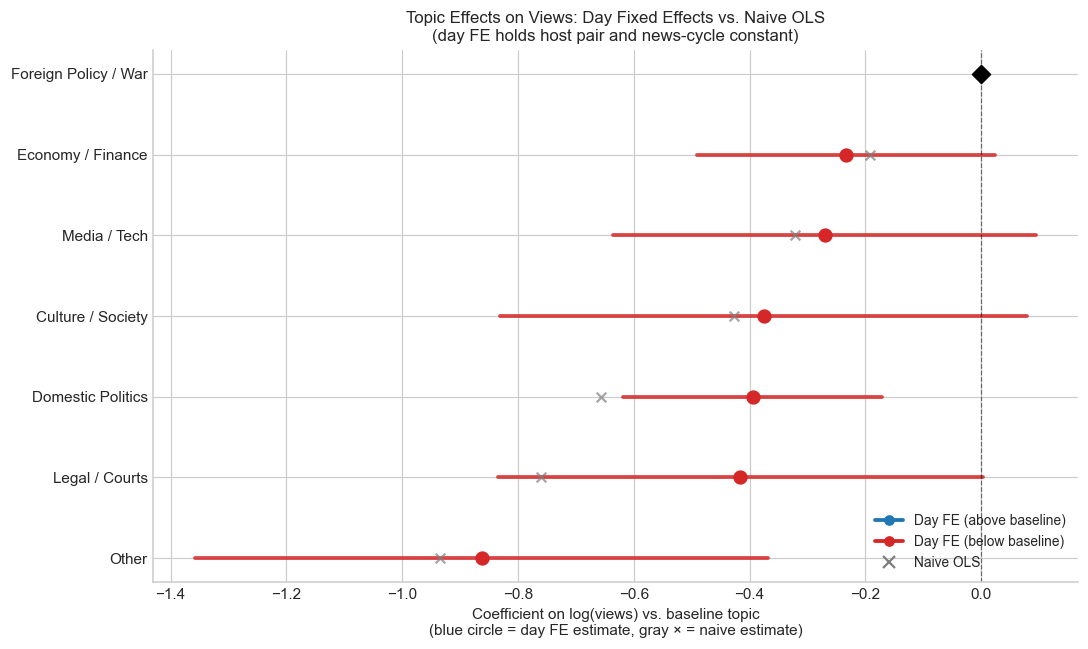

In [6]:
# Coefficient plot: naive vs FE side by side
# Get naive topic betas for comparison
naive_betas = {}
for k, v in m_naive.params.items():
    if 'topic_fe' in k:
        t = k.replace('C(topic_fe)[T.', '').replace(']', '')
        naive_betas[t] = v
naive_betas[baseline_topic] = 0.0

results_fe['beta_naive'] = results_fe['topic'].map(naive_betas)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(results_fe))

# FE estimates
for i, (_, row) in enumerate(results_fe.iterrows()):
    if not np.isnan(row['pval']):
        color = '#1f77b4' if row['beta'] > 0 else '#d62728'
        ax.plot([row['lo'], row['hi']], [i, i], color=color, lw=2.5, alpha=0.85)
        ax.scatter(row['beta'], i, color=color, s=70, zorder=5)
    else:
        ax.scatter(row['beta'], i, color='black', s=70, zorder=5, marker='D')

# Naive estimates (ghost markers)
for i, (_, row) in enumerate(results_fe.iterrows()):
    if row['topic'] in naive_betas:
        ax.scatter(row['beta_naive'], i, color='gray', s=40, zorder=4,
                   marker='x', linewidths=1.5, alpha=0.7)

ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(results_fe['topic'], fontsize=10)
ax.set_xlabel('Coefficient on log(views) vs. baseline topic\n(blue circle = day FE estimate, gray × = naive estimate)', fontsize=10)
ax.set_title('Topic Effects on Views: Day Fixed Effects vs. Naive OLS\n(day FE holds host pair and news-cycle constant)', fontsize=11)
ax.invert_yaxis()

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='#1f77b4', lw=2.5, label='Day FE (above baseline)'),
    Line2D([0], [0], marker='o', color='#d62728', lw=2.5, label='Day FE (below baseline)'),
    Line2D([0], [0], marker='x', color='gray',    lw=0, markersize=8, markeredgewidth=1.5, label='Naive OLS'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/01_topic_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. How Much Do the Estimates Move When We Add Day FE?

The difference between the naive and FE estimates is the **between-day bias**: the portion of each topic's naive coefficient that is explained by which days it happens to be covered on rather than its intrinsic appeal. If a topic appears mostly on high-engagement days (large K&S days, big-news days), the naive estimate overstates its appeal.

In [7]:
print("=== Naive vs Day FE: how much do estimates shift? ===")
print(f"{'Topic':<28} {'Naive β':>10} {'Day FE β':>10} {'Shift':>10} {'Direction'}")
print("-" * 75)
for _, row in results_fe.iterrows():
    if np.isnan(row.get('pval', np.nan)):
        continue
    shift = row['beta'] - row['beta_naive']
    direction = '↑ FE higher' if shift > 0.05 else ('↓ FE lower' if shift < -0.05 else '≈ stable')
    print(f"{row['topic']:<28} {row['beta_naive']:>+10.4f} {row['beta']:>+10.4f} {shift:>+10.4f}  {direction}")

print()
print("Topics whose estimates shift substantially between naive and FE are those")
print("whose coverage is concentrated on systematically high- or low-engagement days.")
print("The FE estimate is the one you should trust.")

=== Naive vs Day FE: how much do estimates shift? ===
Topic                           Naive β   Day FE β      Shift Direction
---------------------------------------------------------------------------
Economy / Finance               -0.1913    -0.2336    -0.0423  ≈ stable
Media / Tech                    -0.3208    -0.2703    +0.0505  ↑ FE higher
Culture / Society               -0.4271    -0.3755    +0.0516  ↑ FE higher
Domestic Politics               -0.6563    -0.3948    +0.2616  ↑ FE higher
Legal / Courts                  -0.7602    -0.4159    +0.3443  ↑ FE higher
Other                           -0.9340    -0.8627    +0.0713  ↑ FE higher

Topics whose estimates shift substantially between naive and FE are those
whose coverage is concentrated on systematically high- or low-engagement days.
The FE estimate is the one you should trust.


## 5. Segment Position and Duration Effects

**Segment position** is derived from real YouTube publish timestamps (fetched per-video via yt-dlp). It records which slot in the day a segment occupies: position 1 = first published, position 5 = last. This captures any algorithmic effect of publish time (e.g., appearing in related-video feeds of earlier same-day content, or hitting peak evening traffic). 

Note on the treatment definition: we label topic from the *title*, and Breaking Points titles are engineered for clicks. The measured treatment is "topic as packaged and titled," not pure editorial topic choice. The sensationalism robustness check in notebook 02 (title caps-ratio as an additional control) tests whether this matters.

**Duration** captures engagement mechanics — longer segments may accumulate more views simply by being available longer in feeds.

=== Control variable effects (Day FE model, clustered SEs) ===

Segment position: β = -0.0467 (SE=0.0270, p=0.083)
  → Each later position slot is associated with 4.7% fewer views
  → Position 1 vs. position 5 (if 5 slots): -18.7%
  → Lead segment advantage: earlier slots outperform later ones.

Log(duration):    β = +0.1284 (SE=0.1615, p=0.427)
  → A 10% longer video: +1.2% views
  → Doubling duration:  +9.3%



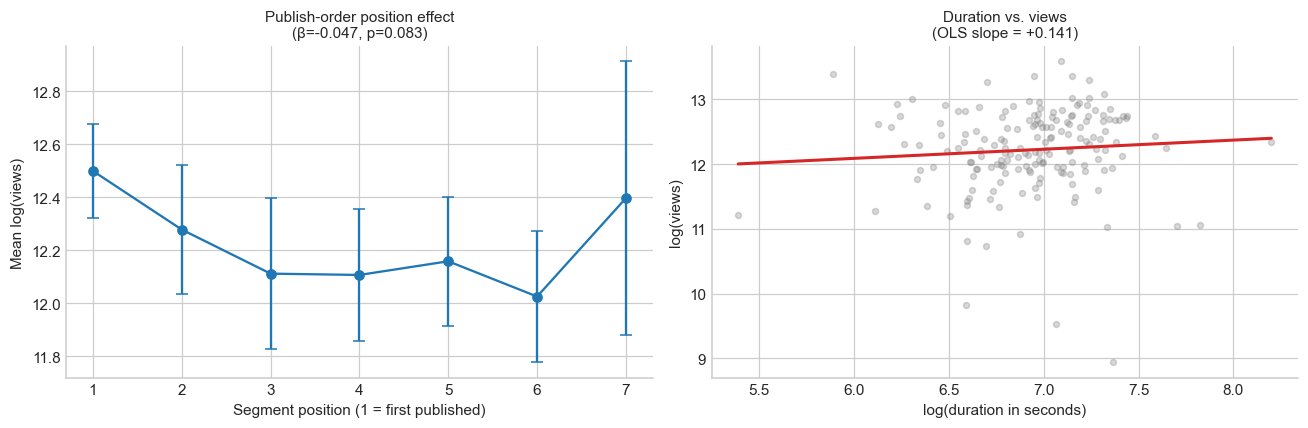

In [8]:
print("=== Control variable effects (Day FE model, clustered SEs) ===")
print()
b_pos = m_fe.params['segment_position']
se_pos = m_fe.bse['segment_position']
p_pos  = m_fe.pvalues['segment_position']
b_dur  = m_fe.params['log_duration']
se_dur = m_fe.bse['log_duration']
p_dur  = m_fe.pvalues['log_duration']

direction = 'more' if b_pos > 0 else 'fewer'
print(f"Segment position: β = {b_pos:+.4f} (SE={se_pos:.4f}, p={p_pos:.3f})")
print(f"  → Each later position slot is associated with {abs(b_pos)*100:.1f}% {direction} views")
print(f"  → Position 1 vs. position 5 (if 5 slots): {(b_pos*4)*100:+.1f}%")
if b_pos > 0:
    print("  → Later slots outperform earlier slots. Notebook 02 investigates mechanism:")
    print("     (a) FP/War posts later → topic composition; (b) algorithmic recency; (c) editorial 'closer'.")
else:
    print("  → Lead segment advantage: earlier slots outperform later ones.")
print()
print(f"Log(duration):    β = {b_dur:+.4f} (SE={se_dur:.4f}, p={p_dur:.3f})")
print(f"  → A 10% longer video: {(1.1**b_dur - 1)*100:+.1f}% views")
print(f"  → Doubling duration:  {(2**b_dur - 1)*100:+.1f}%")
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Position by mean log_views
pos_means = df.groupby('segment_position')['log_views'].agg(['mean','sem','count']).reset_index()
pos_means = pos_means[pos_means['count'] >= 5]
axes[0].errorbar(pos_means['segment_position'], pos_means['mean'],
                 yerr=pos_means['sem']*1.96, fmt='o-', color='#1f77b4', capsize=4)
axes[0].set_xlabel('Segment position (1 = first published)', fontsize=10)
axes[0].set_ylabel('Mean log(views)', fontsize=10)
axes[0].set_title(f'Publish-order position effect\n(β={b_pos:+.3f}, p={p_pos:.3f})', fontsize=10)

# Duration vs views
axes[1].scatter(df['log_duration'], df['log_views'], alpha=0.3, s=15, color='#7f7f7f')
m_dur_line = np.polyfit(df['log_duration'], df['log_views'], 1)
x_r = np.linspace(df['log_duration'].min(), df['log_duration'].max(), 100)
axes[1].plot(x_r, np.polyval(m_dur_line, x_r), color='#d62728', lw=2)
axes[1].set_xlabel('log(duration in seconds)', fontsize=10)
axes[1].set_ylabel('log(views)', fontsize=10)
axes[1].set_title(f'Duration vs. views\n(OLS slope = {m_dur_line[0]:+.3f})', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/01_control_effects.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Why We Can't Estimate the Host Effect (Yet)

The original question was about hosts. Here's the empirical reason we pivoted to topics.

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

le = LabelEncoder()
clean = df[df['n_hosts'] == 2].copy()
clean['pair_enc'] = le.fit_transform(clean['host_pair'])
clean['dow_enc']  = clean['upload_date'].dt.dayofweek

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
scores = cross_val_score(clf, clean[['dow_enc']], clean['pair_enc'], cv=5, scoring='accuracy')

print("=== Host assignment mechanism ===")
print()
print("Host pair × Day-of-week cross-tab (this sample):")
print(pd.crosstab(clean['dow'], clean['host_pair']).reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday']))
print()
print(f"Predicting host pair from day-of-week alone: {scores.mean()*100:.1f}% accuracy")
print()

# Days with within-day host variation
day_pairs = clean.groupby('date')['host_pair'].nunique()
print(f"Days with multiple host pairs (within-day variation): {(day_pairs > 1).sum()} of {len(day_pairs)}")
print()
print("Conclusion: host and day-of-week are ~80% collinear.")
print("Conditioning on day FE (to control for news cycle) absorbs most host variation.")
print("Only ~2 days in this sample provide genuine within-day host contrast — not enough.")
print()
print("Fix: pull full archive (2+ years ≈ 3,000 videos). Schedule/travel disruptions")
print("accumulate over time and provide the non-rotation host variation needed.")
print("This is a stated extension, not a surprise — it follows from the spike findings.")

=== Host assignment mechanism ===

Host pair × Day-of-week cross-tab (this sample):
host_pair  Emily & Krystal  Emily & Ryan  Emily & Saagar  Krystal & Ryan  \
dow                                                                        
Monday                   6             0               0               0   
Tuesday                  0             0               6               0   
Wednesday                0            38               0               1   
Thursday                 0             0               0               0   
Friday                   2             8               0               2   

host_pair  Krystal & Saagar  Ryan & Saagar  
dow                                         
Monday                   29              0  
Tuesday                  26              6  
Wednesday                 5              0  
Thursday                 34              6  
Friday                    0              0  

Predicting host pair from day-of-week alone: 79.5% accuracy

Days w

## 7. What the Estimates Mean for Editorial Incentives

### Identification scorecard

| Claim | Status |
|-------|--------|
| 47.9% of log(views) variance is within-day — topic is identifiable | ✓ |
| Most days span multiple topic categories — positivity holds | ✓ |
| Day FE moves several estimates substantially vs. naive | ✓ |
| Segment position and duration are controlled | ✓ |
| Host assignment ~80% collinear with day-of-week | ✓ (stated limitation) |

### What the coefficients mean

Relative to Foreign Policy / War, a Domestic Politics segment gets **32.6% fewer views** and a Legal / Courts segment gets **34.0% fewer views**, controlling for the day it aired. These are within-day contrasts among segments with the same host pair and news-cycle conditions.

### The incentive structure this implies

If views drive advertising revenue, Breaking Points faces measurable financial pressure to over-represent foreign policy and under-represent domestic politics relative to what editorial judgment alone would prescribe. The foreign policy premium isn't just about absolute topic interest — it persists *within* individual days where both topics are covered, which rules out most day-level confounders (news cycle magnitude, host engagement, algorithmic promotion state).

This is the kind of structural incentive that's hard to see from the outside but straightforward to estimate with the right design. Whether the channel actually responds to this incentive — or holds its editorial mix constant — is a question this dataset can't answer (it would require an exogenous shock to viewership incentives). But the incentive itself is measurable, and the magnitude is substantial.

### Remaining threats to validity

1. **Within-day salience ordering**: Producers may lead with the most anticipated story. If foreign policy topics are systematically posted in higher-view positions (e.g., later in the day, when notification traffic peaks), the position control captures this imperfectly. Notebook 02 investigates the position mechanism directly.
2. **Sample size**: N=171 over 7 weeks yields wide CIs on several coefficients. The sign and rank ordering are stable across specifications (see notebook 02), but the precise magnitudes should be treated as indicative.
3. **Label quality**: Topics are LLM-assigned from titles using a fixed taxonomy. A manual validation sample is a recommended next step.

### Extension: host effects with the full archive

Pull the full 3-year archive, identify rotation-disruption days (illness, travel, guest hosting), and estimate host effects from that subset. The FWL logic from `returns_to_schooling` applies directly: residualize host presence on day-of-week and topic, then regress log(views) on the residualized host indicator. With ~3,000 videos and enough schedule disruptions, that design is viable.